# Challenge 1 — Notebook 1: California Housing Prices

**The Hatch — Penguin Academy**

Análisis exploratorio de datos (EDA) del dataset de precios de casas en California. El objetivo es descubrir qué características explican mejor por qué ciertas casas valen más que otras.

**Estructura del notebook:**
1. Exploración inicial de las características
2. Limpieza de datos
3. Preprocesamiento
4. Análisis simple (univariado)
5. Análisis complejo (bivariado, correlaciones, pairplots, geográfico)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('housing.csv')
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 1. Exploración inicial de las características

Antes de tocar nada, hay que entender qué tenemos: cuántas filas, qué tipos de datos, si hay nulos, y cómo se ve la distribución general de cada columna.


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [3]:
df.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [4]:
# Valores nulos por columna
df.isnull().sum()


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [5]:
# Porcentaje de nulos (relevante para decidir la estrategia de limpieza)
(df.isnull().mean() * 100).round(2)


longitude             0.0
latitude              0.0
housing_median_age    0.0
total_rooms           0.0
total_bedrooms        1.0
population            0.0
households            0.0
median_income         0.0
median_house_value    0.0
ocean_proximity       0.0
dtype: float64

In [6]:
# Variable categórica: distribución de ocean_proximity
df['ocean_proximity'].value_counts()


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

**Hallazgos iniciales:**
- 20,640 filas, 10 columnas.
- `total_bedrooms` tiene 207 nulos (~1% de los datos) — bajo, se puede imputar sin mayor riesgo de sesgo.
- `ocean_proximity` es la única columna categórica (texto), el resto son numéricas.
- La categoría `ISLAND` tiene solo 5 casas — casi no aporta estadísticamente, hay que tenerlo en cuenta al interpretar gráficos segmentados por esta variable.


## 2. Limpieza de datos

### 2.1 Duplicados


In [7]:
print("Filas duplicadas:", df.duplicated().sum())


Filas duplicadas: 0


No hay duplicados exactos, no hace falta eliminar nada acá.

### 2.2 Valores nulos en `total_bedrooms`

Como el porcentaje de nulos es bajo (~1%) pero no despreciable, en vez de eliminar filas (perdiendo información) imputamos con la mediana **agrupada por `ocean_proximity`**, para que la imputación respete el contexto de la zona en vez de aplastar todo con un único valor global.


In [8]:
df['total_bedrooms'] = df.groupby('ocean_proximity')['total_bedrooms']\
    .transform(lambda x: x.fillna(x.median()))

print("Nulos restantes en total_bedrooms:", df['total_bedrooms'].isnull().sum())


Nulos restantes en total_bedrooms: 0


### 2.3 Detección de outliers y censoring en `median_house_value`

El dataset tiene un techo artificial: el censo agrupó todas las casas de más de $500,000 en un único valor ($500,001), en vez de reportar el precio real. Esto **no es un outlier real**, es una limitación de cómo se recolectó el dato — hay que dejarlo documentado en vez de tratarlo como error.


In [9]:
tope = (df['median_house_value'] == 500001).sum()
print(f"Casas en el tope de censoring (500001): {tope} ({tope/len(df)*100:.2f}% del dataset)")


Casas en el tope de censoring (500001): 965 (4.68% del dataset)


In [10]:
# Método IQR para detectar outliers reales (no el censoring)
Q1 = df['median_house_value'].quantile(0.25)
Q3 = df['median_house_value'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['median_house_value'] < limite_inferior) | (df['median_house_value'] > limite_superior)]

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Límite superior: {limite_superior}")
print(f"Cantidad de outliers: {len(outliers)}")
print(f"Porcentaje: {len(outliers) / len(df) * 100:.2f}%")


Q1: 119600.0, Q3: 264725.0, IQR: 145125.0
Límite superior: 482412.5
Cantidad de outliers: 1071
Porcentaje: 5.19%


## 3. Preprocesamiento de datos

`ocean_proximity` es texto, y no puede usarse directamente en cálculos numéricos 
como la correlación. La convertimos a formato numérico con one-hot encoding, ya 
que sus categorías no tienen un orden natural entre sí.

In [11]:
df_encoded = pd.get_dummies(df, columns=['ocean_proximity'])
df_encoded.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False


### Análisis simple: distribución de `median_house_value`

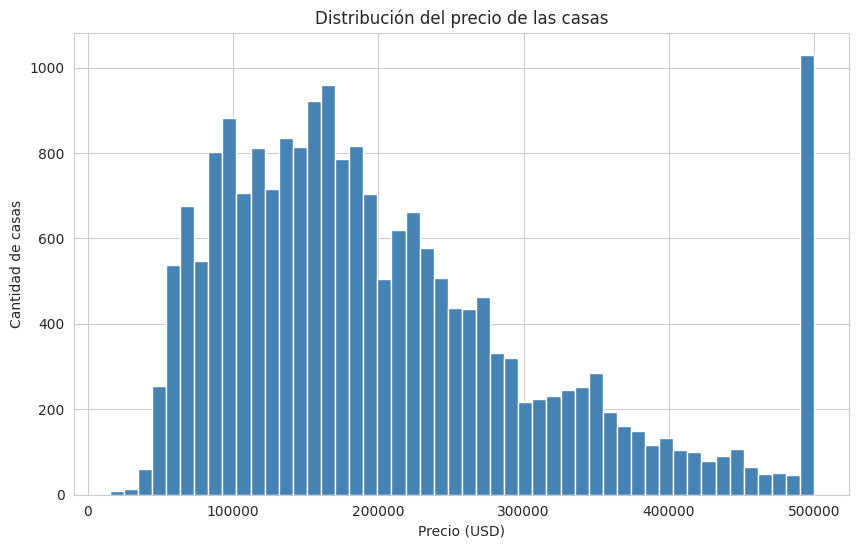

In [12]:
plt.hist(df['median_house_value'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribución del precio de las casas')
plt.xlabel('Precio (USD)')
plt.ylabel('Cantidad de casas')
plt.show()

Mini-reporte de este gráfico:

Situación: graficamos la distribución completa de precios de casas en California.
Hallazgo: la distribución tiene sesgo hacia la derecha, con concentración de casas en el rango $100K-$200K, y una barra artificial de más de 1,000 casas en el tope de $500K por censoring del dataset.
Recomendación: al reportar "cuántas casas caras hay" o "cuál es el precio máximo", aclarar siempre esta limitación — el dataset no permite ver el verdadero techo de precios en California.

### Análisis simple: distribución de `median_income`

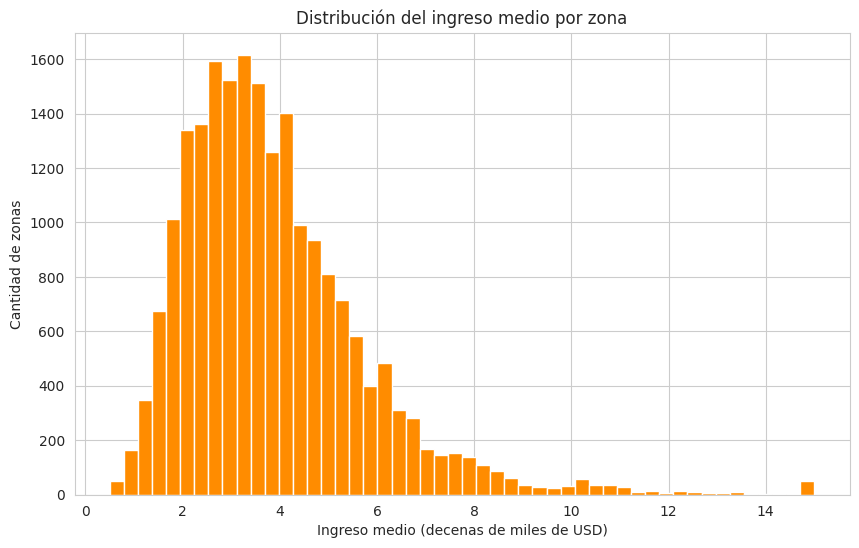

In [13]:
plt.hist(df['median_income'], bins=50, color='darkorange', edgecolor='white')
plt.title('Distribución del ingreso medio por zona')
plt.xlabel('Ingreso medio (decenas de miles de USD)')
plt.ylabel('Cantidad de zonas')
plt.show()

Mini-reporte de este gráfico:

Situación: graficamos la distribución del ingreso medio por zona.
Hallazgo: sesgo hacia la derecha (forma similar a la del precio), con un tope de censoring visible en 15 (~$150,000) — mismo patrón de recolección de datos que ya vimos en median_house_value.
Recomendación: al analizar la relación entre ingreso y precio más adelante, tener presente que ambas variables están truncadas en su extremo superior — cualquier correlación que calculemos podría estar subestimando la relación real entre "zonas muy ricas" y "casas muy caras", porque ambas puntas están cortadas por el dataset.

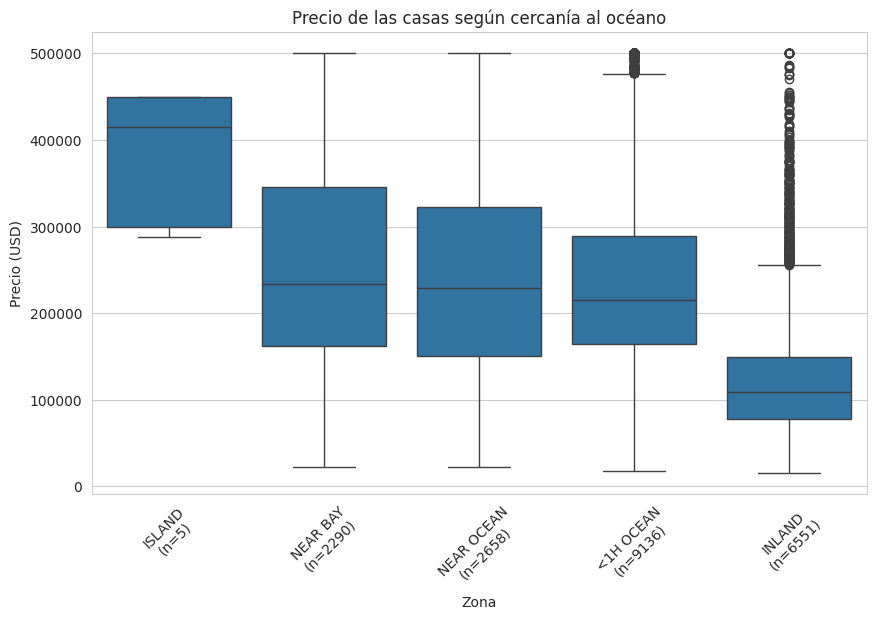

In [14]:
conteo = df['ocean_proximity'].value_counts()
orden = df.groupby('ocean_proximity')['median_house_value'].median().sort_values(ascending=False).index
etiquetas = [f"{cat}\n(n={conteo[cat]})" for cat in orden]

sns.boxplot(x='ocean_proximity', y='median_house_value', data=df, order=orden)
plt.title('Precio de las casas según cercanía al océano')
plt.xlabel('Zona')
plt.ylabel('Precio (USD)')
plt.xticks(ticks=range(len(etiquetas)), labels=etiquetas, rotation=45)
plt.show()

Mini-reporte de este gráfico:

Situación: comparamos el precio de las casas segmentado por zona, corrigiendo el gráfico para no confundir por tamaño de muestra.
Hallazgo: hay una brecha grande entre zonas costeras (NEAR BAY, NEAR OCEAN, <1H OCEAN, medianas ~$210-232K) e INLAND (~$108K). ISLAND, con solo 5 casos, no es una conclusión válida pese a mostrar la mediana más alta.
Recomendación: la cercanía "de cualquier forma" al mar parece ser un factor relevante en el precio, pero no explica todo — hay que revisar si esto es un efecto directo de la ubicación o si está mediado por otra variable (por ejemplo, el ingreso de la zona, que es justo nuestra siguiente hipótesis a probar).

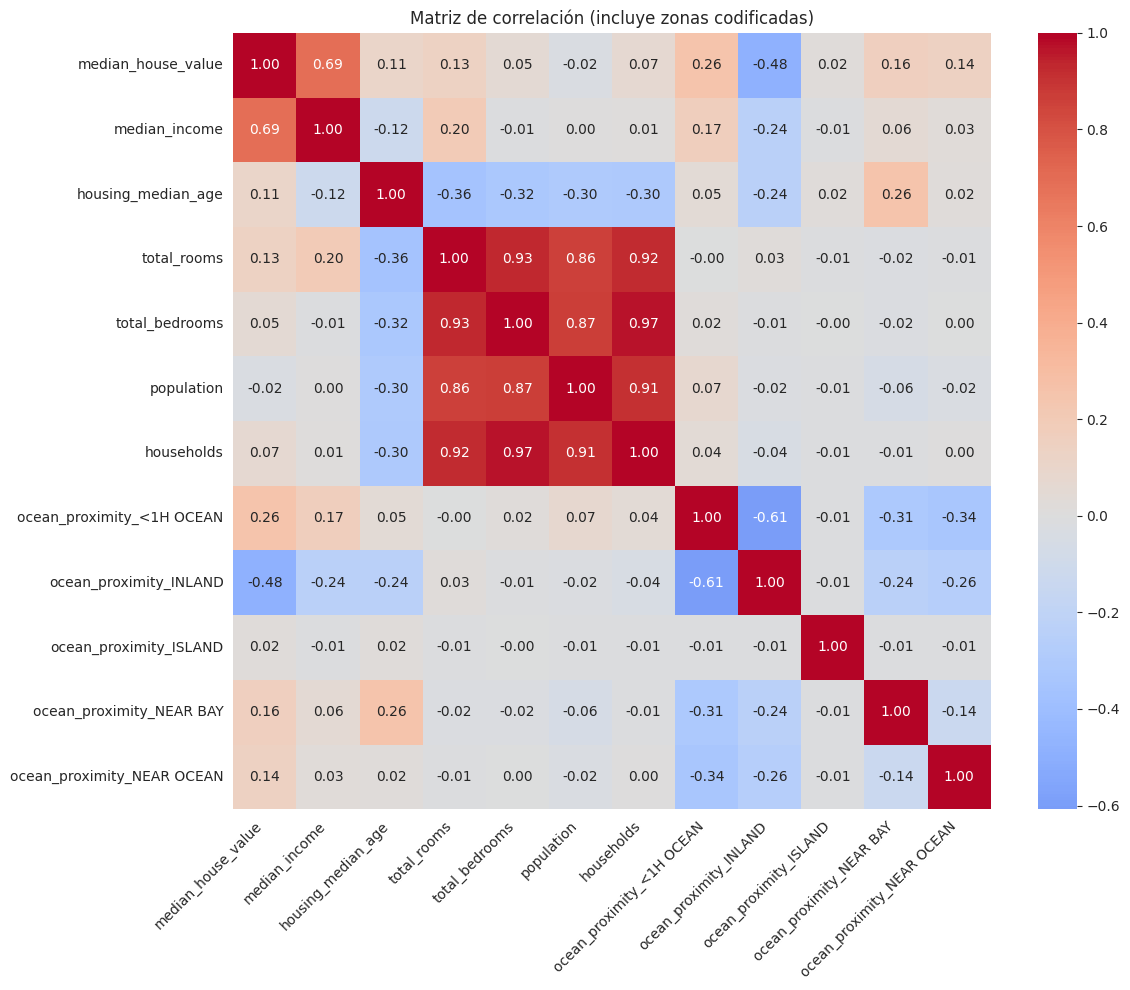

In [15]:
cols_numericas = ['median_house_value', 'median_income', 'housing_median_age',
                   'total_rooms', 'total_bedrooms', 'population', 'households']

# Sumamos las columnas de ocean_proximity ya codificadas (one-hot) en df_encoded
cols_ocean = [c for c in df_encoded.columns if c.startswith('ocean_proximity_')]
cols_para_correlacion = cols_numericas + cols_ocean

corr_matrix = df_encoded[cols_para_correlacion].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación (incluye zonas codificadas)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

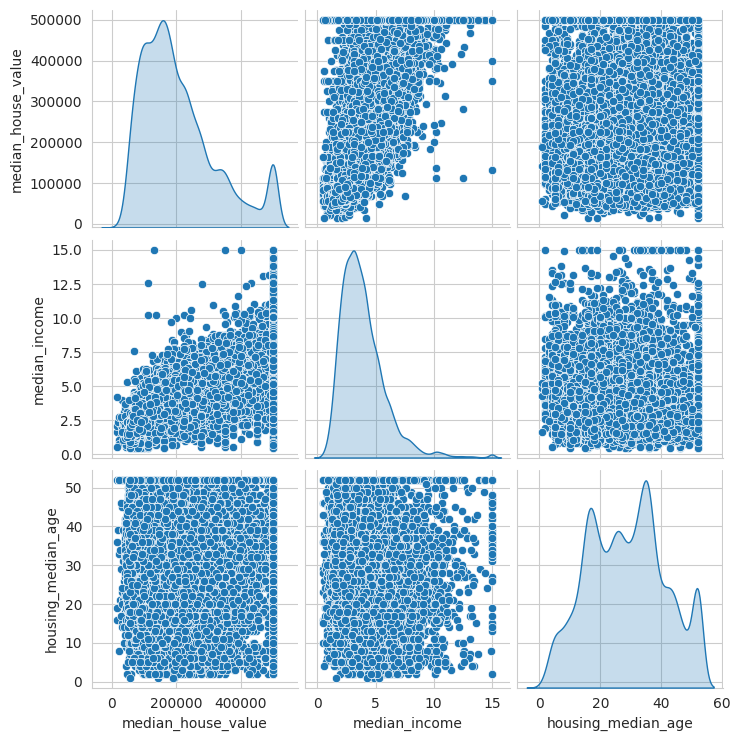

In [16]:
subset = df[['median_house_value', 'median_income', 'housing_median_age']]

sns.pairplot(subset, diag_kind='kde')
plt.show()

Mini-reporte de este pairplot:

Situación: visualizamos las relaciones entre precio, ingreso y edad de la casa con scatterplots.
Hallazgo: se confirma visualmente la relación positiva entre ingreso y precio (la nube sube de izquierda a derecha), mientras que edad de la casa no muestra ninguna tendencia clara con el precio. El pairplot también deja ver, de forma más intuitiva que el histograma, cómo el censoring de $500,001 "aplana" la parte superior de la relación ingreso-precio.
Recomendación: el ingreso sigue siendo la variable más sólida para explicar el precio, tanto por el número (0.69) como por la forma visual de la relación. La conclusión de negocio final: en California, la característica de zona más asociada al valor de una casa es el nivel de ingreso de esa zona, no su antigüedad ni (según vimos antes) exclusivamente su cercanía al mar.

## Conclusiones

- **El ingreso medio de la zona es la variable más asociada al precio** (correlación 0.69), 
  muy por encima de cualquier otra (cuartos, población, antigüedad, todas < 0.15).
- **La cercanía al mar influye**, pero no de forma gradual: cualquier zona costera 
  (NEAR BAY, NEAR OCEAN, <1H OCEAN) supera claramente a INLAND, sin mucha diferencia entre sí.
- **La antigüedad de la casa no tiene relación con el precio** — ni en la correlación 
  ni visualmente en el pairplot.
- **El dataset trunca sus valores extremos:** tanto el precio (tope $500,001) como el 
  ingreso (~$150,000) están censurados, lo que oculta el verdadero rango en zonas caras.

**Conclusión:** el ingreso de la zona explica el precio mejor que cualquier característica 
física de las casas o su ubicación exacta. Esto no implica causalidad — podría ser al 
revés, o ambas variables responder a un tercer factor no incluido en el dataset.